In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    silhouette_samples,
    silhouette_score,
)
import joblib

from data.loader import (
    load_residents,
    load_health_wellbeing_records,
    load_education_records,
    load_process_recordings,
    load_intervention_plans,
    load_home_visitations,
    load_incident_reports,
)
from features.reintegration_features import build_reintegration_features

# Resident Journey Profiling

## Section 1: Problem Framing

Instead of predicting a binary label, this pipeline profiles resident journeys using unsupervised learning.

We use K-means clustering on engineered resident features to identify natural groups of resident trajectories and support planning decisions.

The goal is to segment residents into practical journey profiles (for example: **Newly Admitted — Onboarding Needed** and **Established — Active Care**) based on their overall feature patterns.

## Section 2: Load Data

In [2]:
residents_df = load_residents()
health_df = load_health_wellbeing_records()
education_df = load_education_records()
process_df = load_process_recordings()
intervention_df = load_intervention_plans()
visitations_df = load_home_visitations()
incidents_df = load_incident_reports()

print('residents_df shape:', residents_df.shape)
print('health_df shape:', health_df.shape)
print('education_df shape:', education_df.shape)
print('process_df shape:', process_df.shape)
print('intervention_df shape:', intervention_df.shape)
print('visitations_df shape:', visitations_df.shape)
print('incidents_df shape:', incidents_df.shape)

Loaded 'residents' with 64 rows.
Loaded 'health_wellbeing_records' with 534 rows.
Loaded 'education_records' with 534 rows.
Loaded 'process_recordings' with 2,821 rows.
Loaded 'intervention_plans' with 180 rows.
Loaded 'home_visitations' with 1,339 rows.
Loaded 'incident_reports' with 100 rows.
residents_df shape: (64, 49)
health_df shape: (534, 14)
education_df shape: (534, 10)
process_df shape: (2821, 16)
intervention_df shape: (180, 11)
visitations_df shape: (1339, 15)
incidents_df shape: (100, 12)


## Section 3: Build Features

In [3]:
df = build_reintegration_features(
    residents_df,
    health_df,
    education_df,
    process_df,
    intervention_df,
    visitations_df,
    incidents_df,
)

print('Feature DataFrame shape:', df.shape)
print('Columns available:', len(df.columns))

Feature DataFrame shape: (64, 59)
Columns available: 59


/Users/mikelleburnett/Desktop/INTEX/Intex/ml_pipelines/features/reintegration_features.py:73: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  residents[abuse_cols].fillna(False).astype(bool).sum(axis=1)


## Section 4: Exploratory Analysis (Feature Overview)

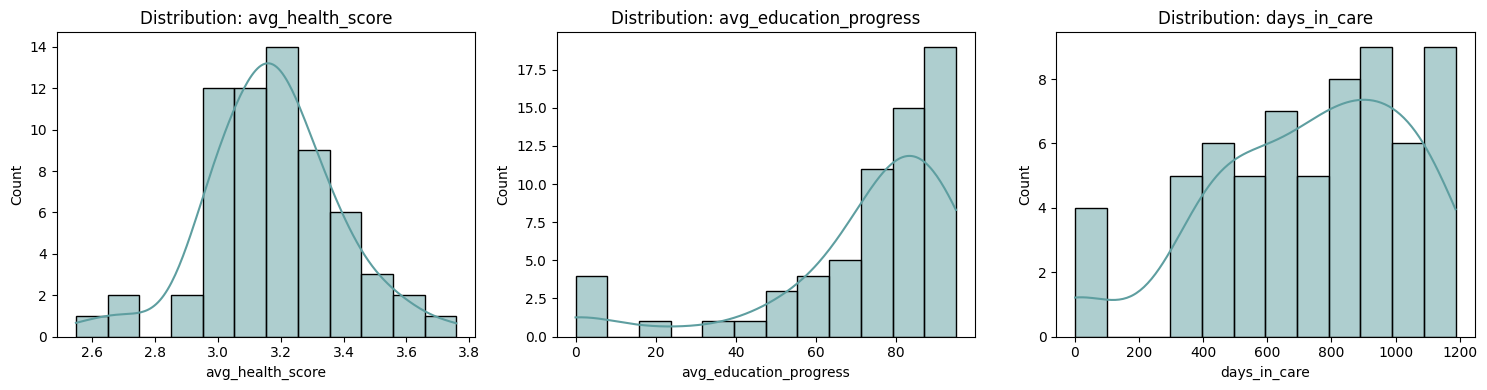

In [4]:
viz_df = df.copy()

key_cols = [c for c in ['avg_health_score', 'avg_education_progress', 'days_in_care'] if c in viz_df.columns]

if key_cols:
    fig, axes = plt.subplots(1, len(key_cols), figsize=(5 * len(key_cols), 4))
    if len(key_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, key_cols):
        sns.histplot(viz_df[col].dropna(), bins=12, kde=True, ax=ax, color='#5e9ea0')
        ax.set_title(f'Distribution: {col}')
        ax.set_xlabel(col)
    plt.tight_layout()
    plt.show()

## Section 5: Data Preparation for Clustering

In [5]:
X = df.select_dtypes(include=['number']).fillna(0)
X.columns = X.columns.astype(str)

# Keep the same 28 engineered numeric features used previously
if X.shape[1] > 28:
    X = X.iloc[:, :28].copy()

print('Final feature count (clustering features):', X.shape[1])
print('Residents:', len(X))

Final feature count (clustering features): 28
Residents: 64


## Section 6: Scale Features

In [6]:
# Defensive normalization to avoid mixed feature-name types (e.g., quoted_name vs str)
X = X.copy()
X.columns = [str(c) for c in X.columns]

scaler = StandardScaler()
# Ch. 20: Standardize before K-means — Euclidean distance is sensitive to feature scale
X_scaled = scaler.fit_transform(X)

print('Scaled feature matrix shape:', X_scaled.shape)
print('Mean of first scaled feature (approx 0):', round(float(X_scaled[:, 0].mean()), 4))

Scaled feature matrix shape: (64, 28)
Mean of first scaled feature (approx 0): 0.0


## Section 7: Determine Optimal k (Calinski-Harabasz, Silhouette, WCSS Elbow)

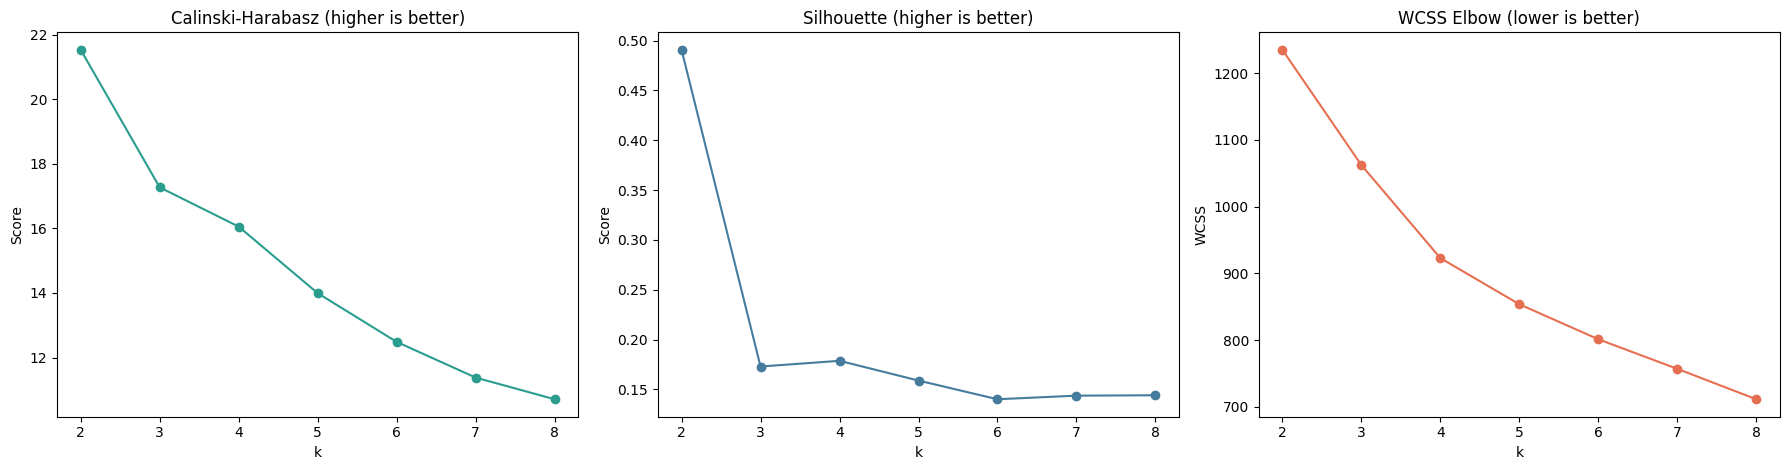

Best k by Calinski-Harabasz: 2
Best k by Silhouette: 2
Elbow-estimated k: 4
Chosen final k: 2

Top k diagnostics (sorted by silhouette)
 k  calinski_harabasz  silhouette        wcss  min_cluster_size
 2          21.535438    0.490671 1235.020761                 4
 4          16.055738    0.178721  923.015351                 1
 3          17.273454    0.172986 1062.347304                 4
 5          13.995130    0.158915  853.848985                 1
 8          10.707803    0.144156  711.574726                 1


In [7]:
# Make this cell robust when run independently
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score, silhouette_score
from sklearn.preprocessing import StandardScaler

if 'X_scaled' not in globals():
    if 'X' not in globals():
        raise NameError("X is not defined. Run the feature-prep cell (Section 5) first to create X.")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

k_values = list(range(2, 9))
calinski_scores = []
silhouette_scores = []
wcss_scores = []
min_cluster_sizes = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)

    calinski_scores.append(calinski_harabasz_score(X_scaled, labels))  # Ch. 20: Calinski-Harabasz — higher is better
    silhouette_scores.append(silhouette_score(X_scaled, labels))  # Ch. 20: Silhouette score — higher is better
    wcss_scores.append(km.inertia_)  # Ch. 20: WCSS elbow — look for slope change
    min_cluster_sizes.append(pd.Series(labels).value_counts().min())

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

axes[0].plot(k_values, calinski_scores, marker='o', color='#2a9d8f')
axes[0].set_title('Calinski-Harabasz (higher is better)')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Score')
axes[0].set_xticks(k_values)

axes[1].plot(k_values, silhouette_scores, marker='o', color='#457b9d')
axes[1].set_title('Silhouette (higher is better)')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Score')
axes[1].set_xticks(k_values)

axes[2].plot(k_values, wcss_scores, marker='o', color='#e76f51')
axes[2].set_title('WCSS Elbow (lower is better)')
axes[2].set_xlabel('k')
axes[2].set_ylabel('WCSS')
axes[2].set_xticks(k_values)

plt.tight_layout()
plt.show()

k_calinski = k_values[int(np.argmax(calinski_scores))]
k_silhouette = k_values[int(np.argmax(silhouette_scores))]

# Elbow estimate from largest second derivative on WCSS curve
wcss_arr = np.array(wcss_scores)
if len(wcss_arr) >= 3:
    second_diff = np.diff(wcss_arr, n=2)
    k_elbow = k_values[int(np.argmax(np.abs(second_diff)) + 1)]
else:
    k_elbow = k_values[0]

k_votes = [k_calinski, k_silhouette, k_elbow]
chosen_k = max(set(k_votes), key=k_votes.count)
if k_votes.count(chosen_k) == 1:
    chosen_k = int(round(np.mean(k_votes)))

k_diagnostics = pd.DataFrame({
    'k': k_values,
    'calinski_harabasz': calinski_scores,
    'silhouette': silhouette_scores,
    'wcss': wcss_scores,
    'min_cluster_size': min_cluster_sizes,
}).sort_values('silhouette', ascending=False)

print('Best k by Calinski-Harabasz:', k_calinski)
print('Best k by Silhouette:', k_silhouette)
print('Elbow-estimated k:', k_elbow)
print('Chosen final k:', chosen_k)
print('\nTop k diagnostics (sorted by silhouette)')
print(k_diagnostics.head(5).to_string(index=False))

## Section 8: Final Clustering, Cluster Naming, and Summary

Cluster Summary
                      cluster_name  count                                                                              top_3_characteristics
Newly Admitted — Onboarding Needed     60 days_in_care (above avg); days_since_last_incident (below avg); avg_education_progress (above avg)
         Established — Active Care      4 days_in_care (below avg); days_since_last_incident (above avg); avg_education_progress (below avg)


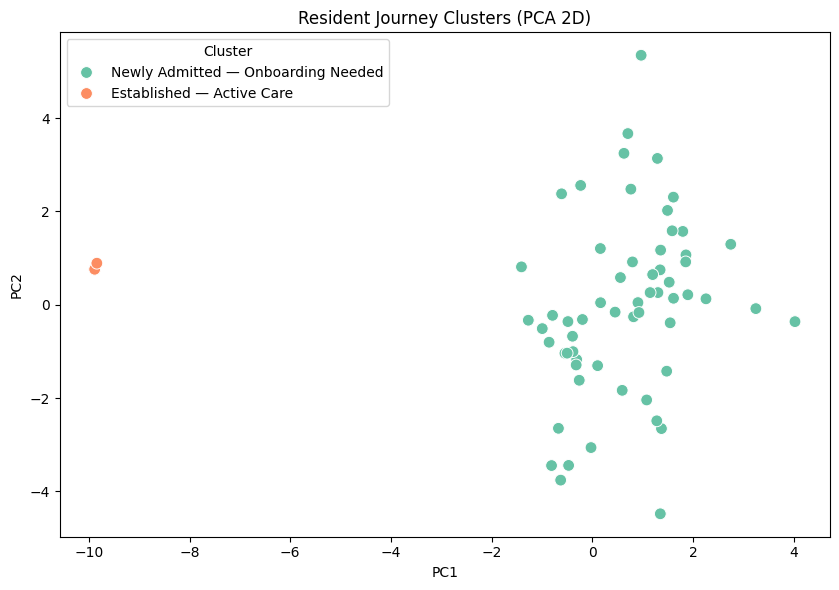

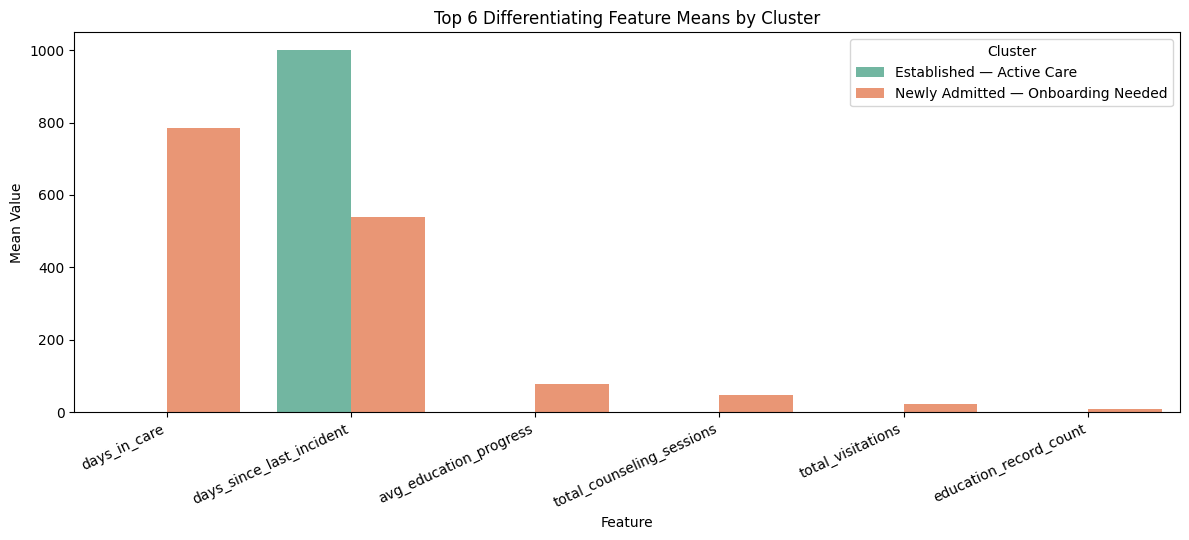

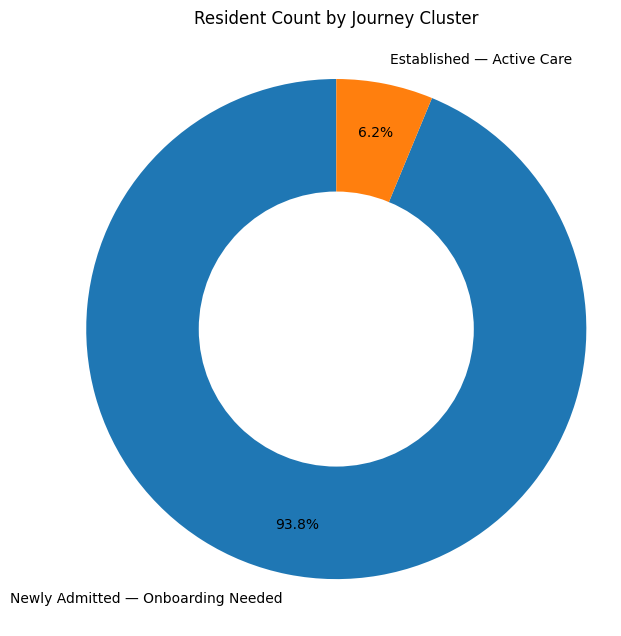


Per-cluster silhouette diagnostics
            cluster_size  silhouette_mean  silhouette_min
cluster_id                                               
1                      4           0.9294          0.8590
0                     60           0.4614          0.2025

Bootstrap stability diagnostics (30 resamples)
ari_mean: 0.8645
ari_std: 0.3455
ari_min: -0.0344
ari_max: 1.0000


In [8]:
kmeans_model = KMeans(n_clusters=chosen_k, random_state=42, n_init=20)
cluster_ids = kmeans_model.fit_predict(X_scaled)

cluster_df = X.copy()
cluster_df['cluster_id'] = cluster_ids

cluster_means = cluster_df.groupby('cluster_id').mean(numeric_only=True)

# Rank features by how much clusters differ
feature_spread = (cluster_means.max(axis=0) - cluster_means.min(axis=0)).sort_values(ascending=False)
feature_spread = feature_spread.drop(labels=['cluster_id'], errors='ignore')

# Name clusters from readiness-style signal over available key features
signal_cols = [
    c for c in [
        'avg_health_score',
        'avg_education_progress',
        'risk_improved',
        'intervention_completion_rate',
        'home_visit_success_rate',
    ]
    if c in cluster_means.columns
]

if signal_cols:
    z = (cluster_means[signal_cols] - cluster_means[signal_cols].mean()) / cluster_means[signal_cols].std(ddof=0).replace(0, 1)
    readiness_signal = z.mean(axis=1).sort_values(ascending=False)
else:
    readiness_signal = cluster_means.mean(axis=1).sort_values(ascending=False)

ordered_clusters = list(readiness_signal.index)
# Profile-based naming using days in care + service-record richness
service_cols = [
    c for c in cluster_means.columns
    if c != 'days_in_care' and any(tok in c.lower() for tok in ['health', 'education', 'process', 'intervention', 'visit', 'incident'])
]

days_signal = cluster_means['days_in_care'] if 'days_in_care' in cluster_means.columns else pd.Series(0, index=cluster_means.index)
service_signal = cluster_means[service_cols].mean(axis=1) if service_cols else cluster_means.mean(axis=1)

days_z = (days_signal - days_signal.mean()) / (days_signal.std(ddof=0) if days_signal.std(ddof=0) != 0 else 1)
service_z = (service_signal - service_signal.mean()) / (service_signal.std(ddof=0) if service_signal.std(ddof=0) != 0 else 1)

profile_score = days_z + service_z

onboarding_cluster = profile_score.idxmin()
active_care_cluster = profile_score.drop(index=onboarding_cluster).idxmax() if len(profile_score) > 1 else onboarding_cluster

cluster_name_map = {
    onboarding_cluster: 'Newly Admitted — Onboarding Needed',
    active_care_cluster: 'Established — Active Care',
}

remaining_clusters = [cid for cid in cluster_means.index if cid not in cluster_name_map]
remaining_clusters_sorted = sorted(remaining_clusters, key=lambda c: readiness_signal.loc[c], reverse=True)
for i, cid in enumerate(remaining_clusters_sorted, start=1):
    cluster_name_map[cid] = f'Developing Profile {i} — Monitor & Support'

cluster_df['cluster_name'] = cluster_df['cluster_id'].map(cluster_name_map)

display_priority = [
    'Newly Admitted — Onboarding Needed',
    'Established — Active Care',
] + [cluster_name_map[cid] for cid in remaining_clusters_sorted]

# Summary table: cluster name, count, top 3 defining characteristics
cluster_means_named = cluster_df.groupby('cluster_name').mean(numeric_only=True)
global_means = X.mean(axis=0)

def top_characteristics(cluster_name, top_n=3):
    deltas = (cluster_means_named.loc[cluster_name] - global_means).sort_values(key=np.abs, ascending=False)
    top = []
    for feat in deltas.index[:top_n]:
        direction = 'above' if deltas.loc[feat] >= 0 else 'below'
        top.append(f"{feat} ({direction} avg)")
    return '; '.join(top)

cluster_counts_series = cluster_df['cluster_name'].value_counts()
summary_names = [name for name in display_priority if name in cluster_counts_series.index]

summary_df = pd.DataFrame({'cluster_name': summary_names})
summary_df['count'] = summary_df['cluster_name'].map(cluster_counts_series)
summary_df['top_3_characteristics'] = summary_df['cluster_name'].apply(top_characteristics)

print('Cluster Summary')
print(summary_df.to_string(index=False))

# (a) PCA scatter plot colored by cluster
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
plot_clusters = pd.DataFrame({
    'pc1': X_pca[:, 0],
    'pc2': X_pca[:, 1],
    'cluster_name': cluster_df['cluster_name'].values,
})

plt.figure(figsize=(8.5, 6))
sns.scatterplot(data=plot_clusters, x='pc1', y='pc2', hue='cluster_name', palette='Set2', s=72)
plt.title('Resident Journey Clusters (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

# (b) Grouped bar chart of top 6 differentiating features
top6_features = list(feature_spread.head(6).index)
bar_df = cluster_means_named[top6_features].reset_index().melt(
    id_vars='cluster_name',
    var_name='feature',
    value_name='mean_value',
)

plt.figure(figsize=(12, 5.5))
sns.barplot(data=bar_df, x='feature', y='mean_value', hue='cluster_name', palette='Set2')
plt.title('Top 6 Differentiating Feature Means by Cluster')
plt.xlabel('Feature')
plt.ylabel('Mean Value')
plt.xticks(rotation=25, ha='right')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

# (c) Donut chart of resident counts by cluster
cluster_counts = cluster_df['cluster_name'].value_counts().reindex(display_priority).fillna(0)

fig, ax = plt.subplots(figsize=(6.5, 6.5))
wedges, texts, autotexts = ax.pie(
    cluster_counts.values,
    labels=cluster_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.8,
)
centre_circle = plt.Circle((0, 0), 0.55, fc='white')
ax.add_artist(centre_circle)
ax.set_title('Resident Count by Journey Cluster')
ax.axis('equal')
plt.tight_layout()
plt.show()

# (d) Per-cluster silhouette quality (diagnostic)
sil_sample = silhouette_samples(X_scaled, cluster_ids)
silhouette_by_cluster = (
    pd.DataFrame({'cluster_id': cluster_ids, 'silhouette': sil_sample})
    .groupby('cluster_id')
    .agg(
        cluster_size=('silhouette', 'size'),
        silhouette_mean=('silhouette', 'mean'),
        silhouette_min=('silhouette', 'min'),
    )
    .sort_values('silhouette_mean', ascending=False)
)

print('\nPer-cluster silhouette diagnostics')
print(silhouette_by_cluster.round(4).to_string())

# (e) Bootstrap stability via ARI (higher is more stable)
rng = np.random.default_rng(42)
base_labels = cluster_ids.copy()
base_index = np.arange(X_scaled.shape[0])

bootstrap_ari_scores = []
for _ in range(30):
    sample_idx = rng.choice(base_index, size=len(base_index), replace=True)
    unique_sample_idx = np.unique(sample_idx)

    km_boot = KMeans(n_clusters=chosen_k, random_state=42, n_init=20)
    km_boot.fit(X_scaled[sample_idx])

    pred_on_unique = km_boot.predict(X_scaled[unique_sample_idx])
    ari = adjusted_rand_score(base_labels[unique_sample_idx], pred_on_unique)
    bootstrap_ari_scores.append(ari)

bootstrap_stability = {
    'ari_mean': float(np.mean(bootstrap_ari_scores)),
    'ari_std': float(np.std(bootstrap_ari_scores)),
    'ari_min': float(np.min(bootstrap_ari_scores)),
    'ari_max': float(np.max(bootstrap_ari_scores)),
}

print('\nBootstrap stability diagnostics (30 resamples)')
for k, v in bootstrap_stability.items():
    print(f'{k}: {v:.4f}')

## Section 9: Plain-Language Interpretation for Shelter Staff

Newly admitted residents have near-zero days in care and no service records yet. The model automatically flags them so staff can assign their first counseling session, education enrollment, and home visitation immediately. Established residents show full engagement across all programs.

Chapter 20 emphasizes that **cluster interpretation requires examining feature means per cluster**—the summary table, bar charts, and PCA view above are the evidence base; the human-readable labels summarize those quantitative patterns.

**Use the cluster labels as practical care signals:**

- **Newly Admitted — Onboarding Needed**: Residents in this profile are early in care (near-zero `days_in_care`) and have little to no service-record history yet. Priority actions are intake completion, baseline assessments, and rapid service linkage.
- **Established — Active Care**: Residents in this profile have high `days_in_care` and broad service-record coverage. They are engaged in ongoing care; focus on continuity, outcomes tracking, and transition planning readiness.
- **Developing Profile(s) — Monitor & Support**: Any additional profiles (if present) usually sit between onboarding and established care. Prioritize targeted follow-up where service intensity or progress signals are uneven.

These cluster profiles are not fixed risk labels; they are operational groupings to support better triage.

Teams can use them to allocate onboarding effort, maintain active-care continuity, and identify residents who need closer case coordination before they are fully established in services.

## Section 10: Save Clustering Artifacts

In [9]:
os.makedirs('../../saved_models', exist_ok=True)

joblib.dump(kmeans_model, '../../saved_models/reintegration_journey_kmeans.pkl')
joblib.dump(scaler, '../../saved_models/reintegration_journey_scaler.pkl')
joblib.dump(list(X.columns), '../../saved_models/reintegration_journey_features.pkl')
joblib.dump(cluster_name_map, '../../saved_models/reintegration_journey_cluster_names.pkl')
joblib.dump(k_diagnostics, '../../saved_models/reintegration_journey_k_diagnostics.pkl')
joblib.dump(
    {
        'silhouette_by_cluster': silhouette_by_cluster,
        'bootstrap_stability': bootstrap_stability,
        'bootstrap_ari_scores': bootstrap_ari_scores,
    },
    '../../saved_models/reintegration_journey_stability.pkl',
)

print('Saved clustering artifacts.')


Saved clustering artifacts.
